# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Report Discussion:**  In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Rivera, Kyle Florian
- _Student No._: 2024-16197
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report figure

#### Problem 1. Wavefunctions of the harmonic oscillator

![First five wavefunctions of the harmonic oscillator](QHOwav.png)

Figure 1. The first five wavefunctions of the harmonic oscillator. Shown in solid black line is the graph of the potential function. Dashed lines indicate the eigenenergy values for the specific eigenfunction.

#### Problem 2. Energy analysis and probability density plot

![Theoretical vs Computed Eigenenergy](EEnergy.png)

Figure 2. $n$th state of the QHO vs the eigenenergy. Note that the theoretical and computed values are overlapping to each other.

![Errors of the eigenenergy](errors.png)

Figure 3. Relative error vs the $n$th state of the QHO.

![Probability density of the QHO in an electric field](ProbDF.png)

Figure 4, Probability density of the ground state of the harmonic oscillator subjected to an electric field.

### Report discussion

In the harmonic oscillator subjected to an electric field, we obtained the eigenenergies to be *almost* similar to the theoretical value, especially for small $n$. As $n$ increases, we see that the relative error increases quadratically. This is due to the truncation error (of order $\mathscr{O}(\Delta x^2)$) brought by discretizing the kinetic energy operator using finite differences. Nevertheless, the error remained below $0.1\%$ even for $n=100$.

Meanwhile, the probability density was found to be Gaussian shifted by $-1$ (could be some other value depending on the constants used), shifting the center to $x=-1$. This is to be expected as the electric field term in the potential does not depend on the position.

Overall, the eigenenergies and ground state wavefunction obtained were identical to what was expected from analytic derivations.

### Other comments
- No comment.

---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=\mathscr{E}_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

> We find that the potential energy operator acting on the wave function at a point $x_i$ i
$$\left[ \hat{V}(x) \psi(x) \right]\Big\vert{}_{x_i} = V(x_i) \psi(x_i) = V_i \psi_i$$
>
> Representing the action of the potential energy operator on the full wave function vector:
$$\hat{V} \begin{bmatrix} \psi_1 \\ \psi_2 \\ \vdots \\ \psi_i \\ \vdots \\ \psi_N \end{bmatrix} = \begin{bmatrix} V_1 \psi_1 \\ V_2 \psi_2 \\ \vdots \\ V_i \psi_i \\ \vdots \\ V_N \psi_N \end{bmatrix}$$
>
> From the kinetic energy operator, we have:
$$\hat{T} = -\frac{\hbar^2}{2m} \frac{\partial^2}{\partial x^2}$$
>
> Applying the operator to a continuous wave function $\psi(x)$ yields
$$\hat{T}\psi = -\frac{\hbar^2}{2m} \frac{\partial^2 \psi}{\partial x^2}$$
$$\hat{T}\psi_i = -\frac{\hbar^2}{2m} \frac{\partial^2 \psi_i}{\partial x^2}$$
>
> We can them approximate the second-order spatial derivative using finite differences:
$$= -\frac{\hbar^2}{2m} \left[ \frac{\psi_{i-1} - 2\psi_i + \psi_{i+1}}{(\Delta x)^2} \right]$$
>
> Expanding this to the entire wavefunction vector, we have
$$\hat{T}\psi_i = -\frac{\hbar^2}{2m(\Delta x)^2} \begin{bmatrix} -2\psi_1 + \psi_2 \\ \psi_1 - 2\psi_2 + \psi_3 \\ \vdots \\ \psi_{i-1} - 2\psi_i + \psi_{i+1} \\ \vdots \\ \psi_{N-1} - 2\psi_N \end{bmatrix}$$
>
> Factoring out the discretized wave function vector into a matrix-vector product:
$$= -\frac{\hbar^2}{2m(\Delta x)^2} \begin{bmatrix} -2 & 1 & 0 & \cdots & 0 \\ 1 & -2 & 1 & \cdots & 0 \\ 0 & 1 & -2 & \cdots & \vdots \\ \vdots & \vdots & \ddots & -2 & 1 \\ 0 & 0 & \cdots & 1 & -2 \end{bmatrix} \begin{bmatrix} \psi_1 \\ \psi_2 \\ \vdots \\ \psi_N \end{bmatrix}$$
>
> Removing the test function vector $\vec{\psi}$ yields the matrix representation of the kinetic energy operator $\hat{T}$:
$$\hat{T} = -\frac{\hbar^2}{2m(\Delta x)^2} \begin{bmatrix} -2 & 1 & 0 & 0 & \cdots & 0 \\ 1 & -2 & 1 & 0 & \cdots & 0 \\ 0 & 1 & -2 & 1 & \cdots & 0 \\ 0 & 0 & \ddots & \ddots & \ddots & \vdots \\ \vdots & \vdots & \cdots & 1 & -2 & 1 \\ 0 & 0 & 0 & 0 & 1 & -2 \end{bmatrix}$$ 

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# global variable
N = 10 # matrix dimension
hbar = 1
m = 1

# set up the kinetic operator matrix
def kinetic_matrix(N):
    kinetic = -2*np.eye(N) + np.roll(np.eye(N), -1, axis=0) + np.roll(np.eye(N), 1, axis=0)
    kinetic[0,-1], kinetic[-1,0] = 0, 0 # we set the non tri-diagonal elements to be zero
    return kinetic

def kinetic_coeff(mass): # hbar and delta x^2 are global variables and doesnt necessarilly change.
    return -(hbar**2) / (2 * mass * delta_x_sq)

def hamiltonian(x_pos, potential_array, mass):
    operator = np.diag(potential_array(x=x_pos)) + kinetic_coeff(mass) * kinetic_matrix(N) # putting it all together
    # print(operator)
    return operator

#hamiltonian(np.ones(10), np.ones(10), 1)

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + \mathscr{E}_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [2]:
%%time
def harmonic_potential(mass=1, omega=1, x=0):
    return (mass*(omega**2)*(x**2)) / 2

N = 3000 # number of points
hbar = 1
x_pos = np.linspace(-100, 100, N)
delta_x_sq = (np.ptp(x_pos)/(N-1))**2 # we take the interval between each point

eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian(x_pos, harmonic_potential, m))
eigenvectors = np.transpose(eigenvectors) # we transpose in order to put the eigenvectors in the same row

CPU times: total: 24.4 s
Wall time: 5.18 s


Notice that we find the values of the wavefunction for $x \in [-100, 100]$. This is to avoid accidentally imposing hard-wall boundary conditions (e.g. particle in a box) to the equation. We take the range to be high enough such that the values vanishes at that point.

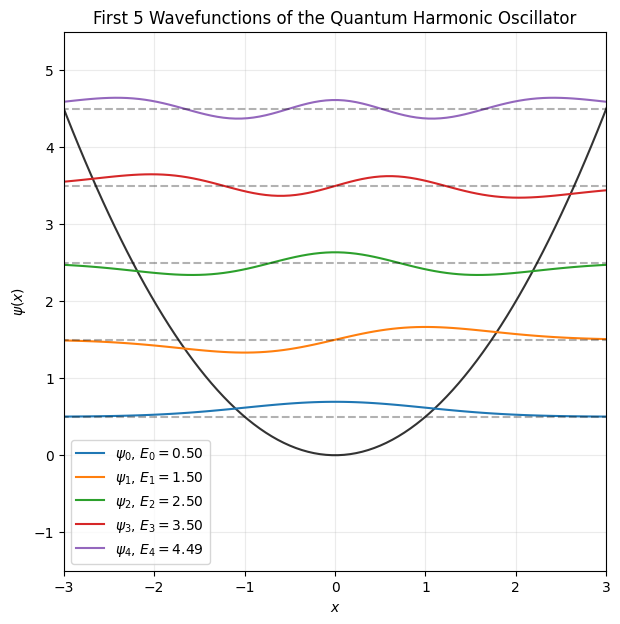

In [3]:
fig, ax = plt.subplots(figsize=(7,7))

ax.plot(x_pos, harmonic_potential(x=x_pos), color='black', alpha=0.8) # we plot the potential

number = 5
settings = [] # we put our plot labels here

for i in range(number):
    settings.append(f"$\\psi_{i}$, $E_{i} = {eigenvalues[i]:.2f}$")

# print(settings)
    
for label, i in zip(settings, range(5)): # and then we plot the eigenfunctions, with an offset equal to its eigenvalue
    ax.plot(x_pos, eigenvectors[i] + eigenvalues[i], label=label)
    ax.plot(x_pos, np.ones(len(x_pos)) * eigenvalues[i], color='black', ls="--", alpha=0.3)

ax.set_xlim(-3,3)
ax.set_ylim(-1.5, 5.5)
ax.set_xlabel("$x$")
ax.set_ylabel(r"$\psi(x)$")
ax.set_title("First 5 Wavefunctions of the Quantum Harmonic Oscillator")
ax.legend()
ax.grid(True, alpha = 0.25)
plt.show()
fig.savefig('QHOwav.png')

The black parabola represents the harmonic potential, while the dashed lines represent the eigenenergies for each eigenfunction.

#### Problem 1 code summary

The code calculates the eigenfunctions of the Quantum Harmonic Oscillator by discretizing the Time-Independent Schrodinger Equation and converting the kinetic and potential energy operators into matrix form. The matrices were constructed by leveraging the symmetric (the tri-diagonal form in particular) properties of the operators. In order to reduce errors, we sample a lot of points and set our evaluation bounds to be sufficiently large ($-100$ to $100$) such that the wave function approximately vanishes at this point.

---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not? (*Note: Set $q=1$ and $E=1$*)

In [4]:
def potential(mass=1, omega=1, x=0, charge=1, field=1):
    return ((mass*(omega**2)*(x**2)) / 2) + (x*charge*field)

def theo_eigenvalue(n=0, hbar=1, omega=1, charge=1, energy=1, mass=1):
    return (hbar*omega * (n + 0.5)) - (((charge**2) * (energy**2))/(2*mass*omega**2))
    
N = 4000 # number of points
hbar = 1
x_pos = np.linspace(-25, 25, N)
delta_x_sq = (np.ptp(x_pos)/(N-1))**2 # we take the interval between each point

eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian(x_pos, potential, m))
eigenvectors = np.transpose(eigenvectors) # we transpose in order to put the eigenvectors in the same row

Similar to the previous problem, we do the same steps but modify our pmotential to include the electric field term.

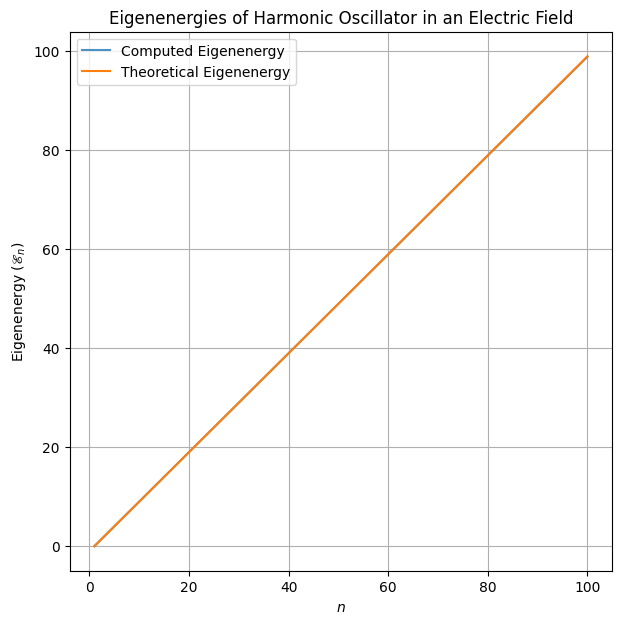

In [5]:
fig, ax = plt.subplots(figsize=(7,7))

no_points = 100
n = np.linspace(1, no_points, no_points) # nth value
theo_eigens = theo_eigenvalue(n=n-1) # takes the nth eigenvalue, we put a minus one so it is zero indexed.
# print(theo_eigens)

ax.plot(n, eigenvalues[0: no_points], alpha=0.8, label="Computed Eigenenergy") # we plot the potential
ax.plot(n, theo_eigens, label="Theoretical Eigenenergy")
ax.set_title("Eigenenergies of Harmonic Oscillator in an Electric Field")
ax.set_xlabel("$n$")
ax.set_ylabel(r"Eigenenergy ($\mathscr{E}_n $)")
ax.legend()
ax.grid(True)
plt.show()
fig.savefig("EEnergy.png")

*Note: Computed and theoretical values are overlaid on top of each other.*
We see that both follow a linear relationship, which is as expected for the QHO. We can try to plot the error at each point.

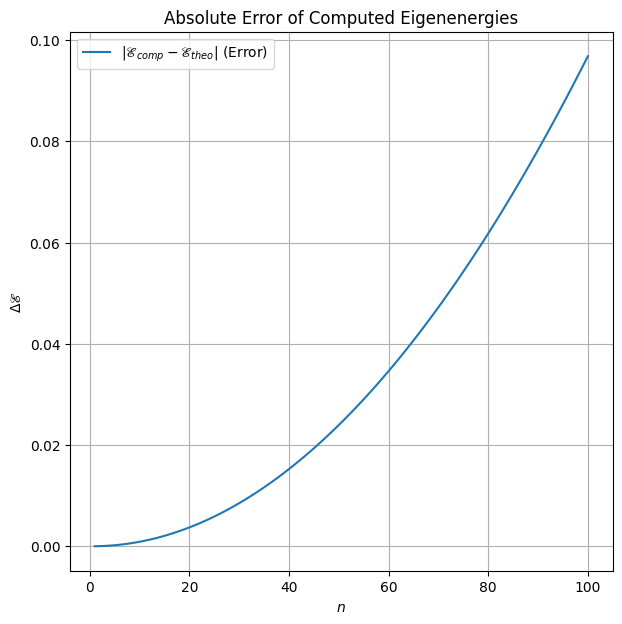

In [6]:
fig, ax = plt.subplots(figsize=(7,7))

ax.plot(n, np.absolute(eigenvalues[0: no_points] - theo_eigens), label = r"$|\mathscr{E}_{comp} - \mathscr{E}_{theo}|$ (Error)")
ax.legend()
ax.set_title("Absolute Error of Computed Eigenenergies")
ax.set_xlabel("$n$")
ax.set_ylabel(r"$\Delta \mathscr{E}$")
ax.grid(True)
plt.show()
fig.savefig("errors.png")

We can see that the linear deviation from the theoretical value increases as we go to a higher eigenenergy.

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

Since our wavefunction is purely real, we can simply square the values to obtain the probability density.

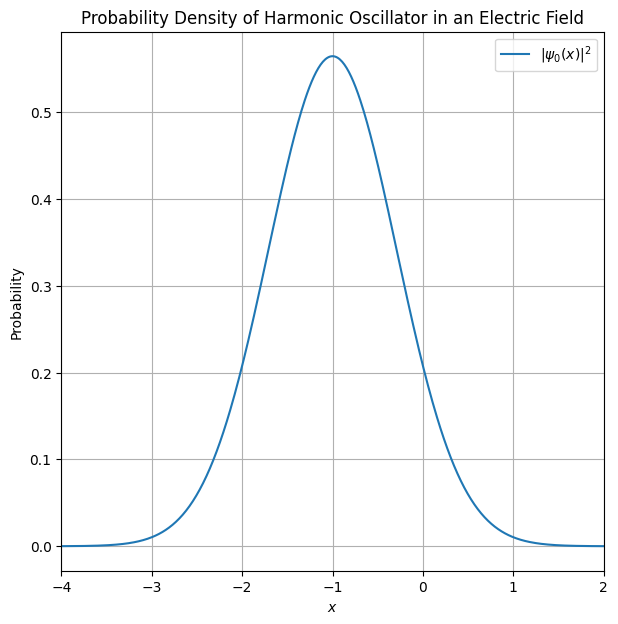

In [7]:
state = 0 # ground state
dx = x_pos[1] - x_pos[0] # since we are dealing with discrete functions, if we take the square, the probability density will not be normalized
prob_den = np.square(eigenvectors[state]) / dx 

fig, ax = plt.subplots(figsize=(7,7))
ax.plot(x_pos, prob_den, label=r"$|\psi_0(x)|^2$")
ax.legend()
ax.set_xlim(-4,2)
ax.set_title("Probability Density of Harmonic Oscillator in an Electric Field")
ax.grid(True)
ax.set_xlabel("$x$")
ax.set_ylabel("Probability")
plt.show()
fig.savefig("ProbDF.png")

#### Problem 2 code summary

The eigenfunctions and eigenenergies of the harmonic oscillator subjected to an electric field was obtained similarly to problem 1. In order to show the error between theoretical and computed eigenenergies, the absolute difference between the two values were calculated. Meanwhile, the probability density was obtained by squaring the eigenvector obtained and multiplying it by a normalization constant in order to ensure that the function is normalized.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)